<a href="https://colab.research.google.com/github/trinhkimngan1602/BaitapAI02/blob/main/4BAITAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 5.8 MB/s eta 0:00:00


===== KẾT QUẢ PHÂN TÍCH =====
Mức giá đề xuất: 94.36%
Mức thưởng tài xế: 91.02%


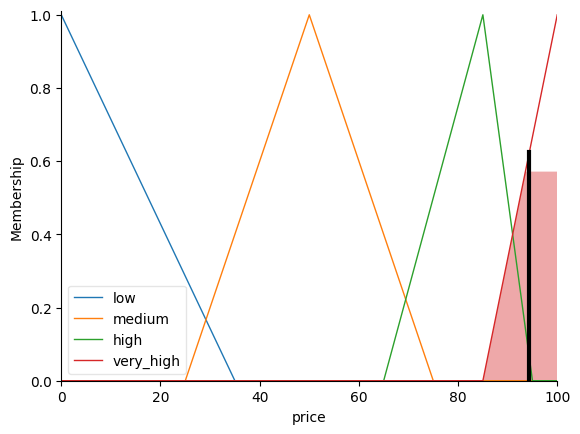

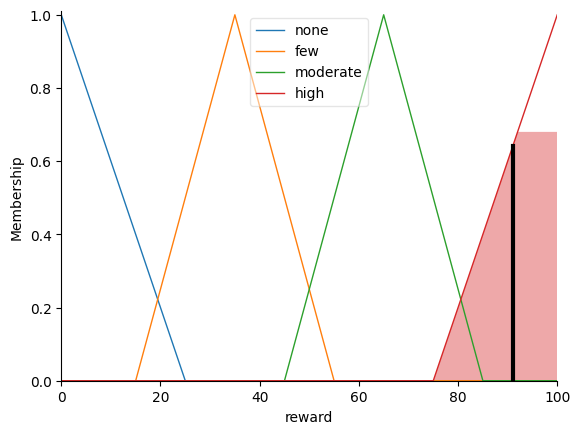

In [2]:

#2.11:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

#input
distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 101, 1), 'weather')
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

#output
price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')

#kcach
distance['short'] = fuzz.trimf(distance.universe, [0, 0, 7])
distance['medium'] = fuzz.trimf(distance.universe, [5, 12, 20])
distance['long'] = fuzz.trimf(distance.universe, [15, 25, 35])
distance['very_long'] = fuzz.trimf(distance.universe, [30, 50, 50])

#giaothong
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 35])
traffic['medium'] = fuzz.trimf(traffic.universe, [25, 50, 75])
traffic['high'] = fuzz.trimf(traffic.universe, [65, 100, 100])

#biennhucau
demand['low'] = fuzz.trimf(demand.universe, [0, 0, 40])
demand['medium'] = fuzz.trimf(demand.universe, [30, 50, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

#
weather['bad'] = fuzz.trimf(weather.universe, [0, 0, 45])
weather['moderate'] = fuzz.trimf(weather.universe, [35, 55, 75])
weather['good'] = fuzz.trimf(weather.universe, [65, 100, 100])

#rating
rating['poor'] = fuzz.trimf(rating.universe, [0, 1, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2, 3.5, 4.5])
rating['good'] = fuzz.trimf(rating.universe, [4, 5, 5])

#độ đúng giờ
punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 55])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [45, 65, 85])
punctuality['early'] = fuzz.trimf(punctuality.universe, [75, 100, 100])

# Giá cả
price['low'] = fuzz.trimf(price.universe, [0, 0, 35])
price['medium'] = fuzz.trimf(price.universe, [25, 50, 75])
price['high'] = fuzz.trimf(price.universe, [65, 85, 95])
price['very_high'] = fuzz.trimf(price.universe, [85, 100, 100])

# Thưởng
reward['none'] = fuzz.trimf(reward.universe, [0, 0, 25])
reward['few'] = fuzz.trimf(reward.universe, [15, 35, 55])
reward['moderate'] = fuzz.trimf(reward.universe, [45, 65, 85])
reward['high'] = fuzz.trimf(reward.universe, [75, 100, 100])

# ================== RULES ==================

rules = [
    # Nhóm quy tắc tính Giá (Price)
    ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium']),
    ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high']),
    ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium']),


    ctrl.Rule(rating['good'] & punctuality['early'], reward['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate']),
    ctrl.Rule(rating['poor'] | punctuality['late'], reward['none']), # Dùng OR để thắt chặt thưởng
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])
]


ride_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(ride_ctrl)


#test

simulation.input['distance'] = 28
simulation.input['traffic'] = 85
simulation.input['demand'] = 80
simulation.input['weather'] = 15
simulation.input['rating'] = 4.8
simulation.input['punctuality'] = 92

simulation.compute()

print("===== KẾT QUẢ PHÂN TÍCH =====")
print(f"Mức giá đề xuất: {simulation.output['price']:.2f}%")
print(f"Mức thưởng tài xế: {simulation.output['reward']:.2f}%")

# Hiển thị biểu đồ kết quả
price.view(sim=simulation)
reward.view(sim=simulation)

------------------------------
KẾT QUẢ PHÂN TÍCH CHIẾT KHẤU
Giá trị tính toán: 17.50%
------------------------------


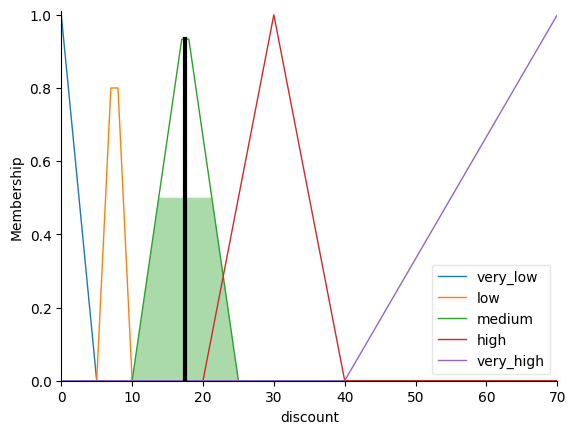

In [5]:
#2.13
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

class ShopeeLuxuryStrategy:
    def __init__(self):
        self.u_perc = np.arange(0, 101, 1)
        self.u_star = np.arange(1, 5.1, 0.1)
        self.u_seas = np.arange(0, 11, 1)
        self.u_disc = np.arange(0, 71, 1)
        self.demand = ctrl.Antecedent(self.u_perc, 'demand')
        self.pressure = ctrl.Antecedent(self.u_perc, 'pressure')
        self.reputation = ctrl.Antecedent(self.u_star, 'reputation')
        self.margin = ctrl.Antecedent(self.u_perc, 'margin')
        self.seasonal = ctrl.Antecedent(self.u_seas, 'seasonal')
        self.discount = ctrl.Consequent(self.u_disc, 'discount')
        self._setup_membership_functions()

    def _setup_membership_functions(self):
        for var in [self.demand, self.pressure]:
            var['low'] = fuzzy.trimf(var.universe, [0, 0, 40])
            var['medium'] = fuzzy.trimf(var.universe, [30, 50, 70])
            var['high'] = fuzzy.trimf(var.universe, [60, 100, 100])

        self.reputation['low'] = fuzzy.trimf(self.u_star, [1, 1, 4.0])
        self.reputation['medium'] = fuzzy.trimf(self.u_star, [3.8, 4.25, 4.7])
        self.reputation['high'] = fuzzy.trimf(self.u_star, [4.5, 5.0, 5.0])

        self.margin['low'] = fuzzy.trimf(self.u_perc, [0, 0, 30])
        self.margin['medium'] = fuzzy.trimf(self.u_perc, [20, 50, 80])
        self.margin['high'] = fuzzy.trimf(self.u_perc, [70, 100, 100])

        self.seasonal['none'] = fuzzy.trimf(self.u_seas, [0, 0, 3])
        self.seasonal['moderate'] = fuzzy.trimf(self.u_seas, [2, 5, 8])
        self.seasonal['high'] = fuzzy.trimf(self.u_seas, [7, 10, 10])

        self.discount['very_low'] = fuzzy.trimf(self.u_disc, [0, 0, 5])
        self.discount['low'] = fuzzy.trimf(self.u_disc, [5, 7.5, 10])
        self.discount['medium'] = fuzzy.trimf(self.u_disc, [10, 17.5, 25])
        self.discount['high'] = fuzzy.trimf(self.u_disc, [20, 30, 40])
        self.discount['very_high'] = fuzzy.trimf(self.u_disc, [40, 70, 70])

    def build_engine(self):
        rules = [
            ctrl.Rule(self.demand['high'] & self.pressure['low'] & self.margin['low'], self.discount['very_low']),
            ctrl.Rule(self.demand['low'] & self.pressure['high'] & self.margin['high'], self.discount['high']),
            ctrl.Rule(self.reputation['high'] & self.margin['medium'] & self.seasonal['high'], self.discount['medium']),
            ctrl.Rule(self.pressure['high'] & self.seasonal['high'] & self.margin['high'], self.discount['very_high']),
            ctrl.Rule(self.reputation['low'] & self.demand['medium'] & self.margin['low'], self.discount['medium']),
            ctrl.Rule(self.demand['high'] & self.seasonal['none'] & self.pressure['low'], self.discount['very_low']),
            ctrl.Rule(self.margin['high'] & self.pressure['medium'] & self.seasonal['moderate'], self.discount['medium'])
        ]
        system = ctrl.ControlSystem(rules)
        return ctrl.ControlSystemSimulation(system)
shopee_ai = ShopeeLuxuryStrategy()
engine = shopee_ai.build_engine()
inputs = {
    'demand': 90,
    'pressure': 50,
    'reputation': 4.2,
    'margin': 85,
    'seasonal': 5
}
for key, value in inputs.items():
    engine.input[key] = value
engine.compute()
print("-" * 30)
print(f"KẾT QUẢ PHÂN TÍCH CHIẾT KHẤU")
print(f"Giá trị tính toán: {engine.output['discount']:.2f}%")
print("-" * 30)
shopee_ai.discount.view(sim=engine)

-> Số lượng đơn nên kết hợp: 8.4 đơn
-> Mức độ ưu tiên giao hàng: 50.00%


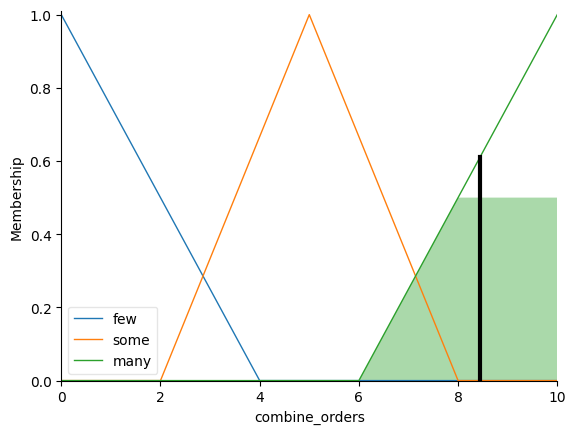

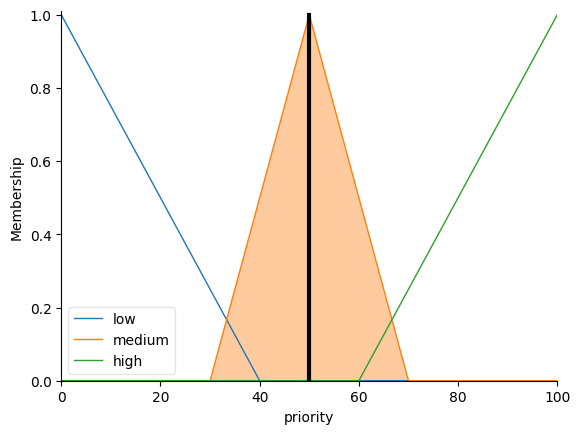

In [6]:
#2.14
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

def setup_logistics_system():
    u_perc = np.arange(0, 101, 1)
    u_order = np.arange(0, 11, 1)

    density = ctrl.Antecedent(u_perc, 'density')
    urgency = ctrl.Antecedent(u_perc, 'urgency')
    driver_load = ctrl.Antecedent(u_perc, 'driver_load')
    traffic = ctrl.Antecedent(u_perc, 'traffic')
    profit = ctrl.Antecedent(u_perc, 'profit')

    combine_orders = ctrl.Consequent(u_order, 'combine_orders')
    priority = ctrl.Consequent(u_perc, 'priority')

    for var in [density, urgency, driver_load, traffic, profit]:
        var['low'] = fuzzy.trimf(var.universe, [0, 0, 40])
        var['medium'] = fuzzy.trimf(var.universe, [30, 50, 70])
        var['high'] = fuzzy.trimf(var.universe, [60, 100, 100])

    combine_orders['few'] = fuzzy.trimf(u_order, [0, 0, 4])
    combine_orders['some'] = fuzzy.trimf(u_order, [2, 5, 8])
    combine_orders['many'] = fuzzy.trimf(u_order, [6, 10, 10])
    priority['low'] = fuzzy.trimf(u_perc, [0, 0, 40])
    priority['medium'] = fuzzy.trimf(u_perc, [30, 50, 70])
    priority['high'] = fuzzy.trimf(u_perc, [60, 100, 100])

    rules = [
        ctrl.Rule(density['high'] & driver_load['low'] & traffic['low'], combine_orders['many']),
        ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine_orders['some']),
        ctrl.Rule(driver_load['high'] & density['high'] & profit['medium'], combine_orders['some']),
        ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine_orders['some']),
        ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine_orders['some']),
        ctrl.Rule(density['high'] & urgency['medium'] & driver_load['low'], combine_orders['many']),
        ctrl.Rule(density['low'] & urgency['low'], combine_orders['few']),
        ctrl.Rule(density['medium'], combine_orders['some']),
        ctrl.Rule(urgency['high'] & profit['high'], priority['high']),
        ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium']),
        ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low']),
        ctrl.Rule(urgency['medium'], priority['medium'])
    ]
    system = ctrl.ControlSystem(rules)
    return ctrl.ControlSystemSimulation(system), combine_orders, priority

logistics_sim, combine_orders_var, priority_var = setup_logistics_system()

test_inputs = {
    'density': 90,
    'urgency': 50,
    'driver_load': 20,
    'traffic': 50,
    'profit': 50
}
for key, value in test_inputs.items():
    logistics_sim.input[key] = value
logistics_sim.compute()
print(f"-> Số lượng đơn nên kết hợp: {logistics_sim.output['combine_orders']:.1f} đơn")
print(f"-> Mức độ ưu tiên giao hàng: {logistics_sim.output['priority']:.2f}%")
combine_orders_var.view(sim=logistics_sim)
priority_var.view(sim=logistics_sim)

 Mức giảm giá đề xuất:        58.33% 


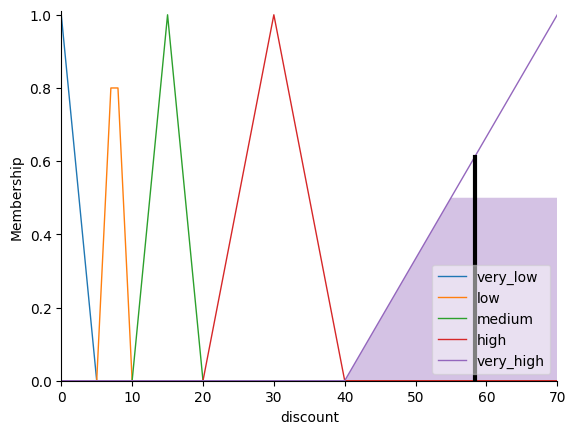

In [7]:
#2.12
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

class ShopeeDiscountOptimizer:
    def __init__(self):

        self.u_rating = np.arange(1, 5.1, 0.1)
        self.u_sales = np.arange(0, 1001, 1)
        self.u_perc = np.arange(0, 101, 1)
        self.u_event = np.arange(0, 11, 1)
        self.u_disc = np.arange(0, 71, 1)
        self.rating = ctrl.Antecedent(self.u_rating, 'rating')
        self.sales = ctrl.Antecedent(self.u_sales, 'sales')
        self.margin = ctrl.Antecedent(self.u_perc, 'margin')
        self.event = ctrl.Antecedent(self.u_event, 'event')
        self.competitor = ctrl.Antecedent(self.u_perc, 'competitor')
        self.discount = ctrl.Consequent(self.u_disc, 'discount')
        self._define_membership_functions()

    def _define_membership_functions(self):
        self.rating['low'] = fuzzy.trimf(self.u_rating, [1, 1, 4.0])
        self.rating['medium'] = fuzzy.trimf(self.u_rating, [3.8, 4.25, 4.7])
        self.rating['high'] = fuzzy.trimf(self.u_rating, [4.5, 5.0, 5.0])
        self.sales['low'] = fuzzy.trimf(self.u_sales, [0, 0, 300])
        self.sales['medium'] = fuzzy.trimf(self.u_sales, [200, 500, 800])
        self.sales['high'] = fuzzy.trimf(self.u_sales, [700, 1000, 1000])

        for var in [self.margin, self.competitor]:
            var['low'] = fuzzy.trimf(self.u_perc, [0, 0, 30 if var.label=='margin' else 20])
            if var.label == 'margin':
                var['medium'] = fuzzy.trimf(self.u_perc, [20, 50, 80])
                var['high'] = fuzzy.trimf(self.u_perc, [70, 100, 100])
            else:
                var['medium'] = fuzzy.trimf(self.u_perc, [15, 40, 65])
                var['high'] = fuzzy.trimf(self.u_perc, [60, 100, 100])

        self.event['none'] = fuzzy.trimf(self.u_event, [0, 0, 3])
        self.event['moderate'] = fuzzy.trimf(self.u_event, [2, 5, 8])
        self.event['high'] = fuzzy.trimf(self.u_event, [7, 10, 10])
        self.discount['very_low'] = fuzzy.trimf(self.u_disc, [0, 0, 5])
        self.discount['low'] = fuzzy.trimf(self.u_disc, [5, 7.5, 10])
        self.discount['medium'] = fuzzy.trimf(self.u_disc, [10, 15, 20])
        self.discount['high'] = fuzzy.trimf(self.u_disc, [20, 30, 40])
        self.discount['very_high'] = fuzzy.trimf(self.u_disc, [40, 70, 70])
    def get_simulation(self):
        rules = [
            ctrl.Rule(self.rating['high'] & self.sales['high'] & self.margin['high'], self.discount['very_low']),
            ctrl.Rule(self.rating['low'] & self.sales['low'] & self.margin['high'], self.discount['high']),
            ctrl.Rule(self.event['high'] & self.competitor['high'], self.discount['very_high']),
            ctrl.Rule(self.rating['medium'] & self.sales['medium'] & self.margin['medium'], self.discount['medium']),
            ctrl.Rule(self.competitor['low'] & self.margin['low'] & self.sales['high'], self.discount['very_low']),
            ctrl.Rule(self.rating['low'] & self.event['none'], self.discount['medium']),
            ctrl.Rule(self.sales['low'] & self.margin['low'], self.discount['very_high'])
        ]
        shopee_ctrl = ctrl.ControlSystem(rules)
        return ctrl.ControlSystemSimulation(shopee_ctrl)
optimizer = ShopeeDiscountOptimizer()
sim_engine = optimizer.get_simulation()

current_case = {
    'rating': 4.3,
    'sales': 500,
    'margin': 15,
    'event': 9,
    'competitor': 80
}
for key, value in current_case.items():
    sim_engine.input[key] = value
sim_engine.compute()
print(f" Mức giảm giá đề xuất: {sim_engine.output['discount']:>12.2f}% ")
optimizer.discount.view(sim=sim_engine)